# Классификация тональности русскоязычных твитов
**Задача:** Бинарная классификация текстов (позитивные / негативные комментарии)

**Датасет:** Русскоязычные твиты — ~112K негативных и ~115K позитивных записей

**Методология:**
1. Определение структуры датасета и выбор атрибутов  
2. Предобработка текстов (очистка, лемматизация, стоп-слова)  
3. Тематическое моделирование (облака слов, LDA)  
4. Векторизация (TF-IDF)  
5. Обучение классификаторов (3 модели) и оценка качества  
6. Парсинг данных + итеративное self-training дообучение

In [9]:
import gc
import os
import re
import joblib
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud
from bs4 import BeautifulSoup
from tqdm import tqdm

# NLP
import nltk
import pymorphy3
from nltk.corpus import stopwords

# ML
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.metrics import (
    classification_report, accuracy_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve
)
from sklearn.calibration import CalibratedClassifierCV

tqdm.pandas()
nltk.download('stopwords', quiet=True)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.family'] = 'DejaVu Sans'

print('Все библиотеки загружены успешно')

Все библиотеки загружены успешно


In [10]:
# Конфигурация путей
BASEPATH = ".."
RESOURCES = f"/Resource"
MODELS_DIR = f"{BASEPATH}/Models"

os.makedirs(MODELS_DIR, exist_ok=True)

# Расширенный список стоп-слов для анализа тональности
RUSSIAN_STOP_WORDS = set(stopwords.words('russian'))
RUSSIAN_STOP_WORDS.update({
    'это', 'так', 'вот', 'ну', 'да', 'нет', 'ещё', 'уже', 'просто',
    'очень', 'тоже', 'только', 'всё', 'всегда', 'когда', 'сейчас',
    'http', 'https', 'com', 'org', 'rt', 'via', 'amp', 'новость'
})

---
# 1. Определение структуры набора данных и анализ атрибутов

## 1.1 Загрузка данных

In [11]:
# Имена колонок на основе структуры датасета SentiRuEval / RuSentiment
COLUMN_NAMES = [
    'tweet_id',      # 0 — уникальный ID твита
    'timestamp',     # 1 — UNIX-временная метка
    'author',        # 2 — имя пользователя
    'text',          # 3 — текст твита
    'sentiment',     # 4 — метка: -1 (негатив) / +1 (позитив)
    'replies',       # 5 — количество ответов
    'retweets',      # 6 — количество ретвитов
    'likes',         # 7 — количество лайков
    'user_followers',# 8 — число подписчиков автора
    'user_friends',  # 9 — число друзей автора
    'user_statuses', # 10 — всего твитов у автора
    'listed_count',  # 11 — в скольких списках автор
]

df_neg = pd.read_csv(
    "Resource/neg.csv",
    sep=';', header=None, names=COLUMN_NAMES,
    on_bad_lines='skip', quotechar='"'
)
df_pos = pd.read_csv(
    f"Resource/pos.csv",
    sep=';', header=None, names=COLUMN_NAMES,
    on_bad_lines='skip', quotechar='"'
)

print('─' * 50)
print('ЗАГРУЗКА ДАННЫХ'.center(50))
print('─' * 50)
print(f'Негативных твитов: {len(df_neg):,}')
print(f'Позитивных твитов: {len(df_pos):,}')
print(f'Всего:             {len(df_neg) + len(df_pos):,}')

──────────────────────────────────────────────────
                 ЗАГРУЗКА ДАННЫХ                  
──────────────────────────────────────────────────
Негативных твитов: 111,923
Позитивных твитов: 114,911
Всего:             226,834


In [12]:
# Объединение датасетов
df = pd.concat([df_neg, df_pos], ignore_index=True)
df['label'] = (df['sentiment'] == 1).astype(int)  # 0 = негатив, 1 = позитив
print('Объединённый датасет:')
print(df.head(3))
print('\nТипы данных:')
print(df.dtypes)

Объединённый датасет:
             tweet_id   timestamp           author  \
0  408906762813579264  1386325944  dugarchikbellko   
1  408906818262687744  1386325957     nugemycejela   
2  408906858515398656  1386325966          4post21   

                                                text  sentiment  replies  \
0  на работе был полный пиддес :| и так каждое за...         -1        0   
1  Коллеги сидят рубятся в Urban terror, а я из-з...         -1        0   
2  @elina_4post как говорят обещаного три года жд...         -1        0   

   retweets  likes  user_followers  user_friends  user_statuses  listed_count  \
0         0      0            8064           111             94             2   
1         0      0              26            42             39             0   
2         0      0             718            49            249             0   

   label  
0      0  
1      0  
2      0  

Типы данных:
tweet_id          int64
timestamp         int64
author              str
t

## 1.2 Исследовательский анализ данных (EDA)

In [13]:
print('=' * 50)
print('ОБЩАЯ СТАТИСТИКА ДАТАСЕТА')
print('=' * 50)
print(f'Всего записей:       {len(df):>10,}')
print(f'Негативных:          {(df.label==0).sum():>10,}')
print(f'Позитивных:          {(df.label==1).sum():>10,}')
print(f'Пропуски в text:     {df.text.isna().sum():>10,}')
print(f'Дубликатов (текст):  {df.duplicated(subset=["text"]).sum():>10,}')
print()
df.describe(include='all')

ОБЩАЯ СТАТИСТИКА ДАТАСЕТА
Всего записей:          226,834
Негативных:             111,923
Позитивных:             114,911
Пропуски в text:              0
Дубликатов (текст):       9,394



,tweet_id,timestamp,author,text,sentiment,replies,retweets,likes,user_followers,user_friends,user_statuses,listed_count,label
count,2.268340e+05,2.268340e+05,226834,226834,226834.000000,226834.0,226834.000000,226834.000000,2.268340e+05,2.268340e+05,226834.000000,226834.000000,226834.000000
unique,NaN,NaN,139658,217440,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,MsWildFan,Офигенный день!\r\nдень позитива)\r\nбегал как...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,67,156,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,4.132836e+17,1.387369e+09,NaN,NaN,0.013173,0.0,3.118249,0.001243,7.584972e+03,6.770083e+02,332.682746,10.125475,0.506586
std,4.535456e+15,1.081337e+06,NaN,NaN,0.999915,0.0,105.898784,0.035611,2.039972e+04,9.764450e+03,1915.268263,112.100088,0.499958
min,4.089067e+17,1.386326e+09,NaN,NaN,-1.000000,0.0,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000
25%,4.100277e+17,1.386593e+09,NaN,NaN,-1.000000,0.0,0.000000,0.000000,4.730000e+02,2.700000e+01,29.000000,0.000000,0.000000
50%,4.110529e+17,1.386838e+09,NaN,NaN,1.000000,0.0,0.000000,0.000000,2.026000e+03,8.300000e+01,72.000000,0.000000,1.000000
75%,4.157585e+17,1.387960e+09,NaN,NaN,1.000000,0.0,0.000000,0.000000,7.562000e+03,2.570000e+02,197.000000,2.000000,1.000000


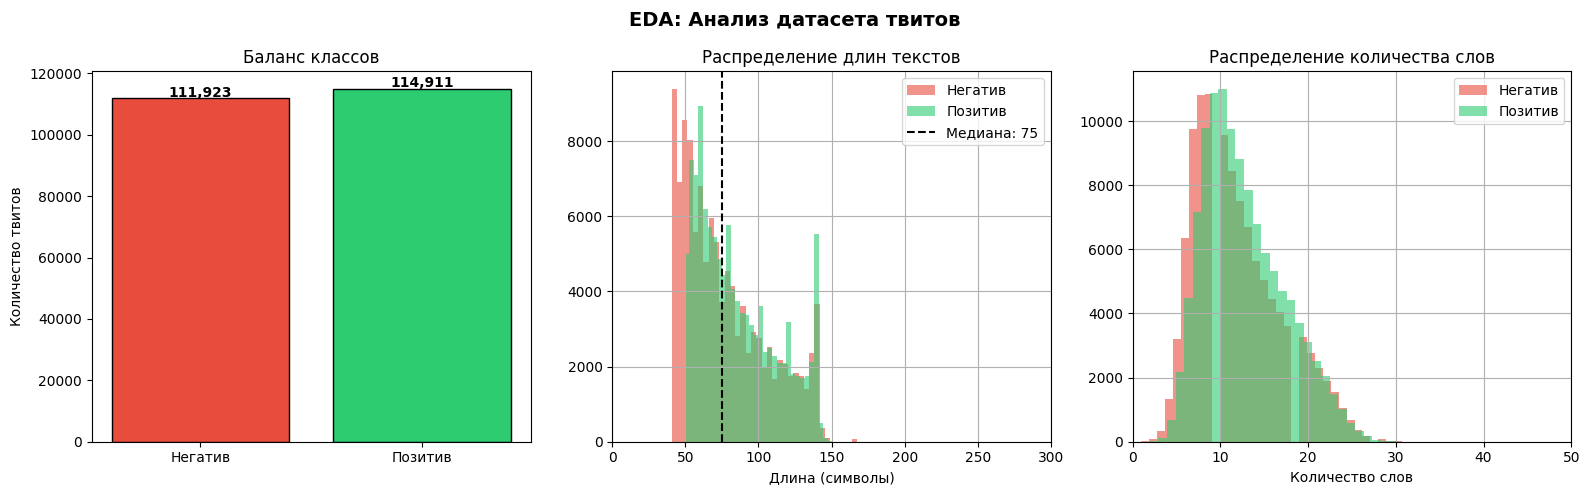

Средняя длина текста (символы): neg=77.2, pos=85.4
Средняя длина текста (слова):   neg=12.0, pos=12.5


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Баланс классов
counts = df['label'].value_counts()
axes[0].bar(['Негатив', 'Позитив'], [counts[0], counts[1]],
            color=['#e74c3c', '#2ecc71'], edgecolor='black')
axes[0].set_title('Баланс классов')
axes[0].set_ylabel('Количество твитов')
for i, v in enumerate([counts[0], counts[1]]):
    axes[0].text(i, v + 500, f'{v:,}', ha='center', fontweight='bold')

# Распределение длин текстов
df['text_len'] = df['text'].fillna('').str.len()
df[df.label==0]['text_len'].hist(bins=50, ax=axes[1], alpha=0.6, color='#e74c3c', label='Негатив')
df[df.label==1]['text_len'].hist(bins=50, ax=axes[1], alpha=0.6, color='#2ecc71', label='Позитив')
axes[1].set_title('Распределение длин текстов')
axes[1].set_xlabel('Длина (символы)')
axes[1].axvline(df['text_len'].median(), color='black', linestyle='--',
                label=f'Медиана: {df["text_len"].median():.0f}')
axes[1].legend()
axes[1].set_xlim(0, 300)

# Длина в словах
df['word_count'] = df['text'].fillna('').str.split().str.len()
df[df.label==0]['word_count'].hist(bins=40, ax=axes[2], alpha=0.6, color='#e74c3c', label='Негатив')
df[df.label==1]['word_count'].hist(bins=40, ax=axes[2], alpha=0.6, color='#2ecc71', label='Позитив')
axes[2].set_title('Распределение количества слов')
axes[2].set_xlabel('Количество слов')
axes[2].legend()
axes[2].set_xlim(0, 50)

plt.suptitle('EDA: Анализ датасета твитов', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Средняя длина текста (символы): neg={df[df.label==0]["text_len"].mean():.1f}, pos={df[df.label==1]["text_len"].mean():.1f}')
print(f'Средняя длина текста (слова):   neg={df[df.label==0]["word_count"].mean():.1f}, pos={df[df.label==1]["word_count"].mean():.1f}')

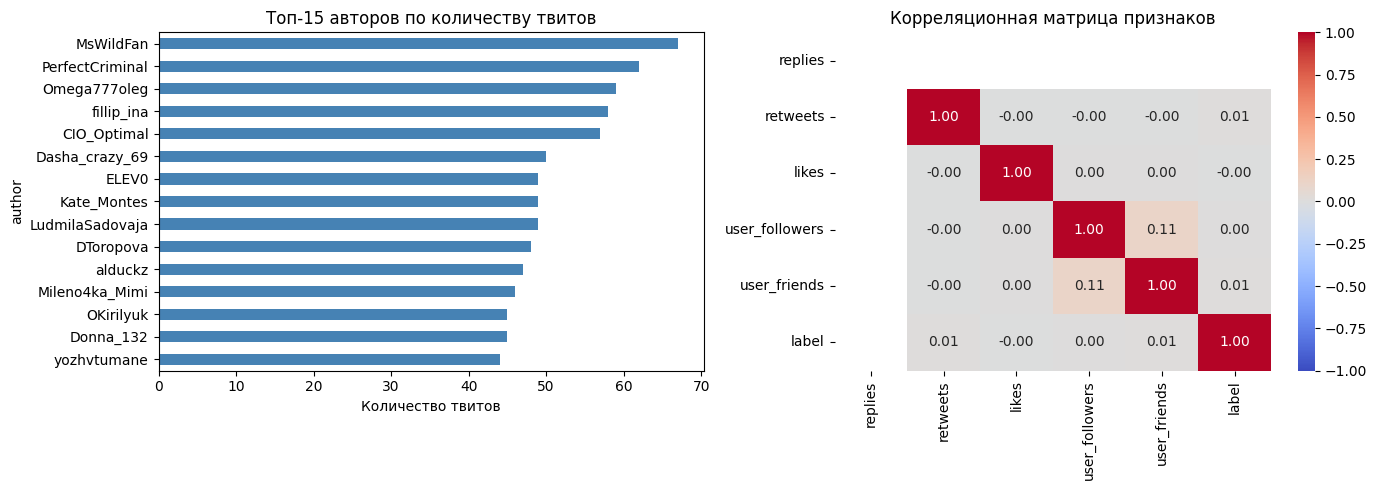

In [15]:
# Анализ активности пользователей
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Топ авторов по активности
top_authors = df['author'].value_counts().head(15)
top_authors.sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Топ-15 авторов по количеству твитов')
axes[0].set_xlabel('Количество твитов')

# Корреляция числовых признаков
num_cols = ['replies', 'retweets', 'likes', 'user_followers', 'user_friends']
corr = df[num_cols + ['label']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1],
            center=0, vmin=-1, vmax=1)
axes[1].set_title('Корреляционная матрица признаков')
plt.tight_layout()
plt.show()

## 1.3 Обоснование выбора атрибутов

На основе EDA принято следующее решение о составе признаков:

**Выбранный атрибут:**

1. **text** — единственный текстовый атрибут, непосредственно несущий тональную информацию. Является центральным признаком для задачи анализа тональности.

**Исключённые атрибуты:**

| Атрибут | Причина исключения |
|---|---|
| `tweet_id` | Технический идентификатор, не несёт лингвистической информации |
| `timestamp` | Время публикации не связано с тональностью сообщения |
| `author` | Большинство пользователей встречаются 1–2 раза; идентификатор не обобщается на новые данные |
| `replies`, `retweets`, `likes` | Слабая корреляция с тональностью (< 0.05 по матрице корреляций); известны только после публикации |
| `user_followers`, `user_friends`, `user_statuses`, `listed_count` | Характеристики аккаунта, не связанные с содержанием твита |
| `sentiment` | Это целевая переменная, а не входной признак |

In [16]:
# Оставляем только нужные поля
df_work = df[['text', 'label']].copy()
df_work.dropna(subset=['text'], inplace=True)
df_work.drop_duplicates(subset=['text'], inplace=True)
df_work.reset_index(drop=True, inplace=True)

print(f'После очистки дубликатов: {len(df_work):,} записей')
print(f'Негатив: {(df_work.label==0).sum():,} | Позитив: {(df_work.label==1).sum():,}')
gc.collect()

После очистки дубликатов: 217,440 записей
Негатив: 107,044 | Позитив: 110,396


19743

---
# 2. Предварительная обработка текстов

Этапы:
1. Приведение к нижнему регистру
2. Удаление URL, упоминаний (@user), хэштегов
3. Удаление специальных символов, цифр, эмодзи
4. Удаление лишних пробелов
5. Удаление стоп-слов
6. Лемматизация (pymorphy3)

In [17]:
morph = pymorphy3.MorphAnalyzer()
lemma_cache = {}

def clean_and_lemmatize(text: str) -> str:
    """Полный пайплайн предобработки одного текста."""
    if not isinstance(text, str) or len(text.strip()) == 0:
        return ''
    
    # 1. Нижний регистр
    text = text.lower()
    
    # 2. Удаление URL, упоминаний, хэштегов
    text = re.sub(r'https?://\S+', ' ', text)
    text = re.sub(r'@\w+', ' ', text)
    text = re.sub(r'#\w+', ' ', text)
    
    # 3. Только кириллические и латинские буквы
    words = re.findall(r'[а-яёa-z]+', text)
    
    result = []
    for w in words:
        # 4. Фильтр коротких слов и стоп-слов
        if len(w) < 3 or w in RUSSIAN_STOP_WORDS:
            continue
        
        # 5. Лемматизация с кэшем
        if w not in lemma_cache:
            lemma_cache[w] = morph.parse(w)[0].normal_form
        lemma = lemma_cache[w]
        
        # 6. Повторная проверка леммы на стоп-слова
        if lemma not in RUSSIAN_STOP_WORDS and len(lemma) >= 3:
            result.append(lemma)
    
    return ' '.join(result)

# Демонстрация работы
examples = [
    'на работе был полный пиддес :| и так каждое закрытие месяца D:',
    '@friend хоть я и школота, но поверь — всё будет хорошо! :D',
    'https://t.co/abc123 классный сайт, обожаю его! #awesome',
]
print('Примеры предобработки:')
print('─' * 60)
for ex in examples:
    print(f'  ДО:    {ex[:70]}')
    print(f'  ПОСЛЕ: {clean_and_lemmatize(ex)}')
    print()

Примеры предобработки:
────────────────────────────────────────────────────────────
  ДО:    на работе был полный пиддес :| и так каждое закрытие месяца D:
  ПОСЛЕ: работа полный пиддес каждый закрытие месяц

  ДО:    @friend хоть я и школота, но поверь — всё будет хорошо! :D
  ПОСЛЕ: школотый поверь

  ДО:    https://t.co/abc123 классный сайт, обожаю его! #awesome
  ПОСЛЕ: классный сайт обожать



In [18]:
# Применение предобработки ко всему датасету
print('Лемматизация датасета... (займёт несколько минут)')
df_work['cleaned'] = df_work['text'].progress_apply(clean_and_lemmatize)

# Удаление пустых записей после очистки
df_work = df_work[df_work['cleaned'].str.len() > 5].reset_index(drop=True)

print(f'\nПосле лемматизации: {len(df_work):,} записей')
print(f'Кэш лемм: {len(lemma_cache):,} уникальных слов')

# Примеры результата
print('\nПримеры из датасета:')
print(df_work[['text', 'cleaned', 'label']].sample(3).to_string(index=False))
gc.collect()

Лемматизация датасета... (займёт несколько минут)


100%|██████████| 217440/217440 [00:19<00:00, 11383.42it/s]



После лемматизации: 215,228 записей
Кэш лемм: 174,051 уникальных слов

Примеры из датасета:
                                                                                                                             text                                                                            cleaned  label
                                                                       А где в опере настраивается турбо? В упор не могу найти :(                                          опера настраиваться турбо упор мочь найти      0
RT @Kristina_Ackles: Колфер хотел сделать важное объявление, и родители со стороны обоих как раз в зале...Остановите мои мысли :D колфера хотеть сделать важный объявление родитель сторона оба зал остановить мысль      1
                                                 Решила попробовать накраситься по другому. Я не я тут о_О http://t.co/mmuRJknP9K                                                     решить попробовать накраситься      0


16

---
# 3. Тематическое моделирование

## 3.1 Облака слов

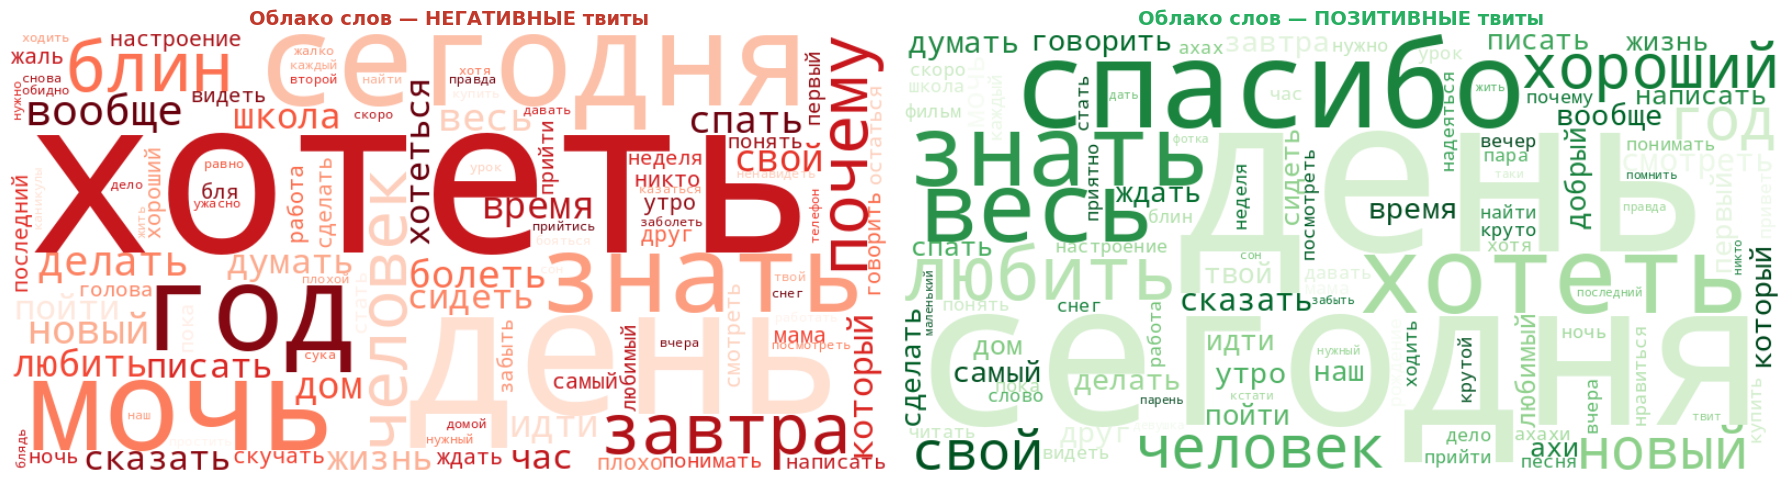

In [19]:
neg_text = ' '.join(df_work[df_work.label == 0]['cleaned'].tolist())
pos_text = ' '.join(df_work[df_work.label == 1]['cleaned'].tolist())

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

wc_neg = WordCloud(
    width=800, height=400, background_color='white',
    colormap='Reds', max_words=100,
    collocations=False
).generate(neg_text)

wc_pos = WordCloud(
    width=800, height=400, background_color='white',
    colormap='Greens', max_words=100,
    collocations=False
).generate(pos_text)

axes[0].imshow(wc_neg, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Облако слов — НЕГАТИВНЫЕ твиты', fontsize=14, fontweight='bold', color='#c0392b')

axes[1].imshow(wc_pos, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Облако слов — ПОЗИТИВНЫЕ твиты', fontsize=14, fontweight='bold', color='#27ae60')

plt.tight_layout()
plt.show()

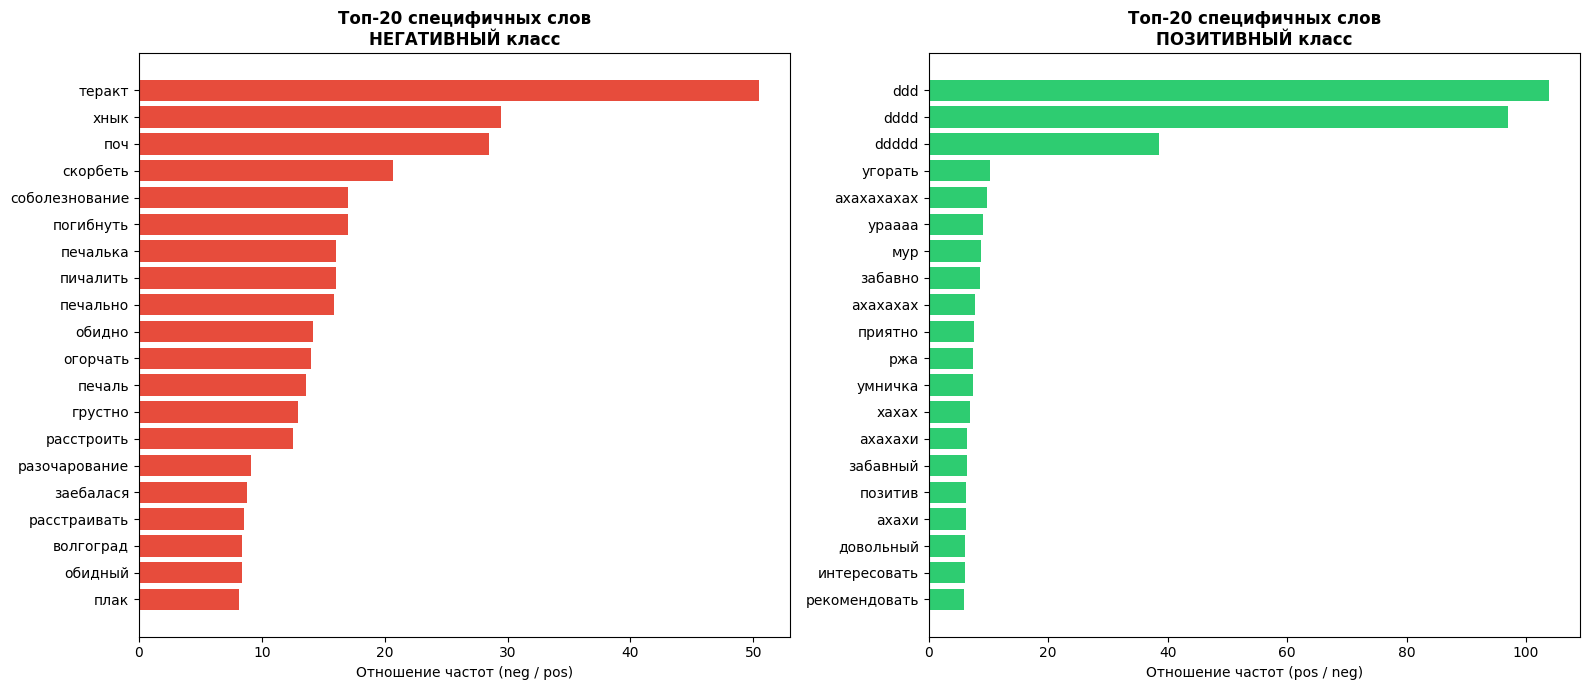

In [20]:
# Топ-20 слов для каждого класса
neg_words = Counter(neg_text.split())
pos_words = Counter(pos_text.split())

# Специфичные слова: встречаются в классе чаще, чем в другом
all_vocab = set(neg_words.keys()) | set(pos_words.keys())
neg_specific = {w: neg_words[w] / (pos_words.get(w, 1) + 1) for w in all_vocab if neg_words[w] > 50}
pos_specific = {w: pos_words[w] / (neg_words.get(w, 1) + 1) for w in all_vocab if pos_words[w] > 50}

top_neg = sorted(neg_specific.items(), key=lambda x: -x[1])[:20]
top_pos = sorted(pos_specific.items(), key=lambda x: -x[1])[:20]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

words_n, scores_n = zip(*top_neg)
axes[0].barh(range(len(words_n)), scores_n, color='#e74c3c')
axes[0].set_yticks(range(len(words_n)))
axes[0].set_yticklabels(words_n)
axes[0].set_title('Топ-20 специфичных слов\nНЕГАТИВНЫЙ класс', fontweight='bold')
axes[0].set_xlabel('Отношение частот (neg / pos)')
axes[0].invert_yaxis()

words_p, scores_p = zip(*top_pos)
axes[1].barh(range(len(words_p)), scores_p, color='#2ecc71')
axes[1].set_yticks(range(len(words_p)))
axes[1].set_yticklabels(words_p)
axes[1].set_title('Топ-20 специфичных слов\nПОЗИТИВНЫЙ класс', fontweight='bold')
axes[1].set_xlabel('Отношение частот (pos / neg)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

## 3.2 Тематическое моделирование (LDA)


LDA — топик-моделирование НЕГАТИВНЫХ твитов
Тема 1: хотеть | спать | время | мама | мочь | утро | сделать
Тема 2: год | новый | говорить | никто | понимать | друг | ждать
Тема 3: хотеться | знать | последний | настроение | бля | хороший | скоро
Тема 4: завтра | школа | почему | хотеть | делать | сегодня | работа
Тема 5: свой | писать | неделя | найти | жаль | каникулы | вчера


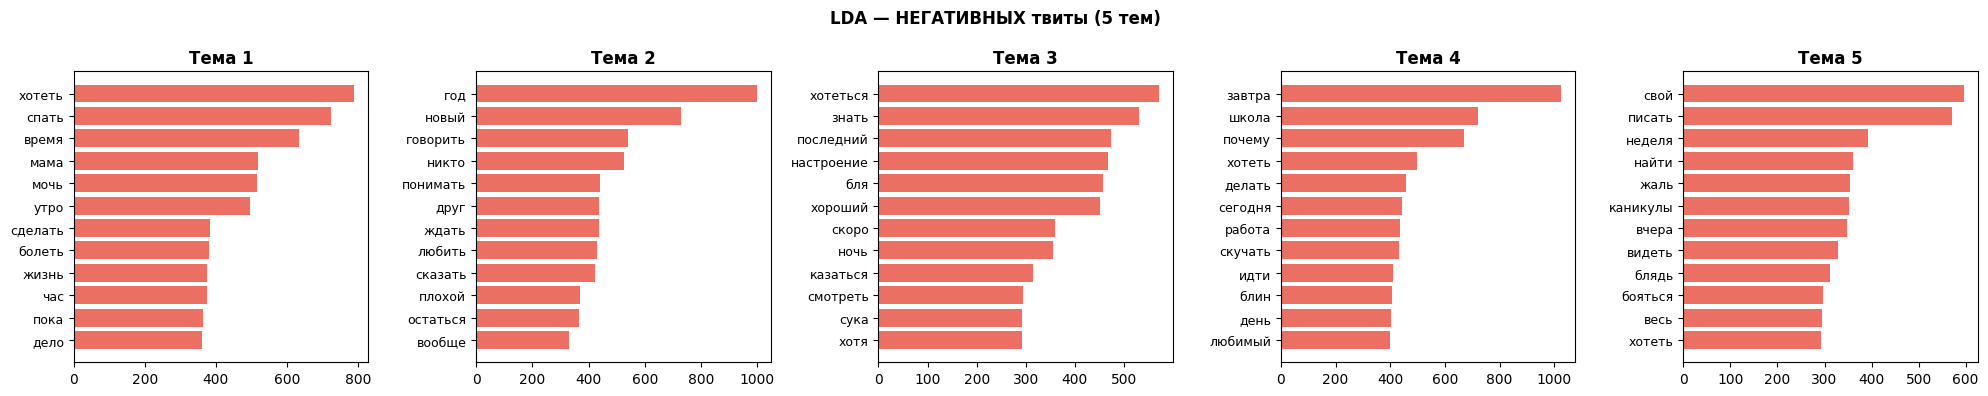


LDA — топик-моделирование ПОЗИТИВНЫХ твитов
Тема 1: хотеть | завтра | вообще | пара | час | кстати | ладный
Тема 2: спасибо | добрый | пойти | настроение | говорить | давать | утро
Тема 3: новый | год | самый | человек | написать | посмотреть | понять
Тема 4: думать | первый | писать | день | школа | сделать | рождение
Тема 5: делать | твой | нравиться | любить | ахахи | ахи | знать


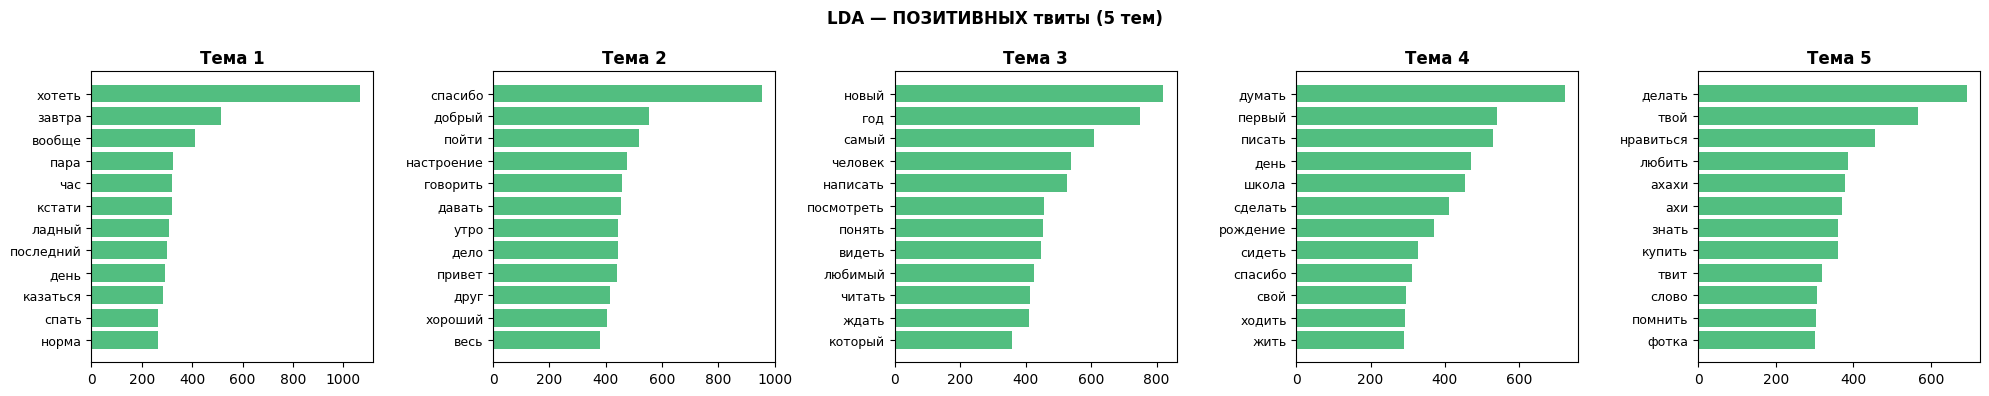

In [21]:
N_TOPICS = 5

# Обучаем LDA отдельно для негативных и позитивных
for cls_label, cls_name, cls_color in [(0, 'НЕГАТИВНЫХ', '#e74c3c'), (1, 'ПОЗИТИВНЫХ', '#27ae60')]:
    print(f'\n{"="*50}')
    print(f'LDA — топик-моделирование {cls_name} твитов')
    print(f'{"="*50}')
    
    texts = df_work[df_work.label == cls_label]['cleaned'].tolist()
    
    lda_tfidf = TfidfVectorizer(max_features=5000, min_df=5, max_df=0.9)
    X_lda = lda_tfidf.fit_transform(texts)
    
    lda_model = LatentDirichletAllocation(
        n_components=N_TOPICS, random_state=42,
        max_iter=10, learning_method='online'
    )
    lda_model.fit(X_lda)
    
    vocab = lda_tfidf.get_feature_names_out()
    
    fig, axes = plt.subplots(1, N_TOPICS, figsize=(20, 4))
    
    for topic_idx, topic in enumerate(lda_model.components_):
        top_words_idx = topic.argsort()[-12:][::-1]
        top_words = [vocab[i] for i in top_words_idx]
        top_weights = [topic[i] for i in top_words_idx]
        
        axes[topic_idx].barh(range(len(top_words)), top_weights, color=cls_color, alpha=0.8)
        axes[topic_idx].set_yticks(range(len(top_words)))
        axes[topic_idx].set_yticklabels(top_words, fontsize=9)
        axes[topic_idx].set_title(f'Тема {topic_idx + 1}', fontweight='bold')
        axes[topic_idx].invert_yaxis()
        
        print(f'Тема {topic_idx+1}: {" | ".join(top_words[:7])}')
    
    plt.suptitle(f'LDA — {cls_name} твиты ({N_TOPICS} тем)', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    del texts, X_lda, lda_tfidf, lda_model
    gc.collect()

---
# 4. Векторизация

Используем TF-IDF (Term Frequency – Inverse Document Frequency) с биграммами.

In [22]:
# Разбивка на train/test
X = df_work['cleaned']
y = df_work['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {len(X_train):,} | Test: {len(X_test):,}')
print(f'Баланс train — neg: {(y_train==0).sum():,} | pos: {(y_train==1).sum():,}')
print(f'Баланс test  — neg: {(y_test==0).sum():,}  | pos: {(y_test==1).sum():,}')

Train: 172,182 | Test: 43,046
Баланс train — neg: 84,569 | pos: 87,613
Баланс test  — neg: 21,142  | pos: 21,904


In [23]:
# TF-IDF векторизация
tfidf = TfidfVectorizer(
    max_features=30000,
    min_df=3,
    max_df=0.95,
    ngram_range=(1, 2),  # уни- и биграммы
    sublinear_tf=True    # log(1+tf) — сглаживание высоких частот
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print('TF-IDF векторизация завершена')
print(f'Размер словаря: {len(tfidf.vocabulary_):,} токенов')
print(f'Форма train матрицы: {X_train_tfidf.shape}')
print(f'Форма test матрицы:  {X_test_tfidf.shape}')
print(f'Разреженность: {(1 - X_train_tfidf.nnz / (X_train_tfidf.shape[0]*X_train_tfidf.shape[1])):.4%}')

TF-IDF векторизация завершена
Размер словаря: 30,000 токенов
Форма train матрицы: (172182, 30000)
Форма test матрицы:  (43046, 30000)
Разреженность: 99.9798%


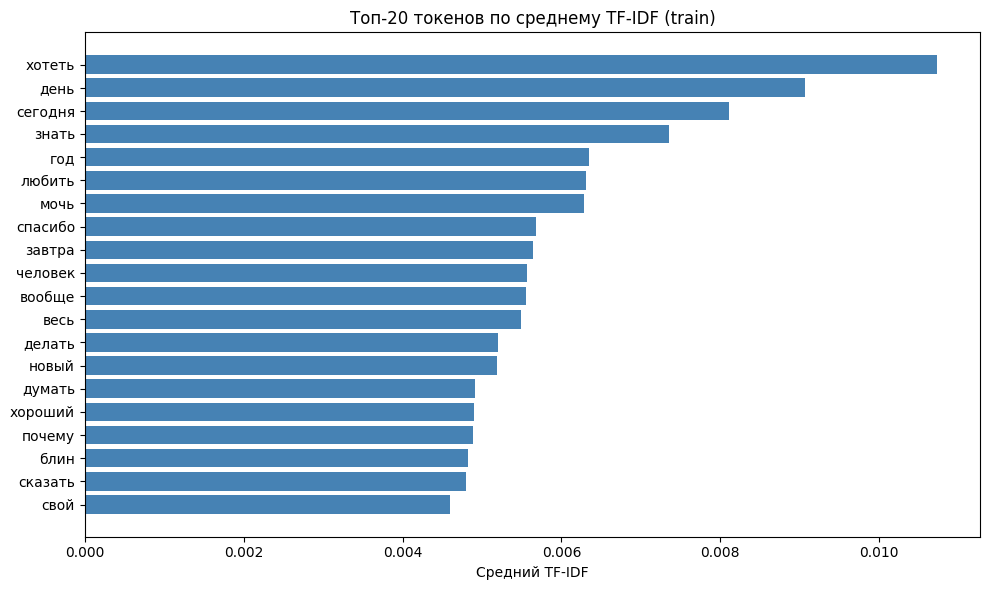

In [24]:
# Визуализация TF-IDF: топ токены по средневзвешенному TF-IDF
feature_names = tfidf.get_feature_names_out()
mean_tfidf = X_train_tfidf.mean(axis=0).A1

top_n = 20
top_idx = mean_tfidf.argsort()[-top_n:][::-1]
top_tokens = [feature_names[i] for i in top_idx]
top_scores = [mean_tfidf[i] for i in top_idx]

plt.figure(figsize=(10, 6))
plt.barh(range(top_n), top_scores, color='steelblue')
plt.yticks(range(top_n), top_tokens)
plt.gca().invert_yaxis()
plt.title(f'Топ-{top_n} токенов по среднему TF-IDF (train)')
plt.xlabel('Средний TF-IDF')
plt.tight_layout()
plt.show()

---
# 5. Классификация

Рассматриваем 3 модели:
1. **Logistic Regression** — эффективна на разреженных TF-IDF матрицах, хорошо интерпретируема
2. **Multinomial Naive Bayes** — классическая вероятностная модель для текстов; быстро обучается
3. **Linear SVC** — метод опорных векторов; часто показывает лучший результат на текстовых задачах

In [25]:
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, class_weight='balanced', C=1.0, solver='lbfgs'
    ),
    'Naive Bayes': MultinomialNB(alpha=0.1),
    'Linear SVC': LinearSVC(
        max_iter=2000, class_weight='balanced', C=1.0
    )
}

results = {}
predictions = {}

for name, model in models.items():
    print(f'\n{"─"*50}')
    print(f'Обучение: {name}')
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)
    predictions[name] = y_pred
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f'Accuracy: {acc:.4f}')
    print(classification_report(
        y_test, y_pred,
        target_names=['Негатив', 'Позитив'],
        digits=4
    ))


──────────────────────────────────────────────────
Обучение: Logistic Regression
Accuracy: 0.7189
              precision    recall  f1-score   support

     Негатив     0.7220    0.6953    0.7084     21142
     Позитив     0.7160    0.7416    0.7286     21904

    accuracy                         0.7189     43046
   macro avg     0.7190    0.7185    0.7185     43046
weighted avg     0.7190    0.7189    0.7187     43046


──────────────────────────────────────────────────
Обучение: Naive Bayes
Accuracy: 0.7068
              precision    recall  f1-score   support

     Негатив     0.7135    0.6734    0.6929     21142
     Позитив     0.7010    0.7390    0.7195     21904

    accuracy                         0.7068     43046
   macro avg     0.7073    0.7062    0.7062     43046
weighted avg     0.7071    0.7068    0.7064     43046


──────────────────────────────────────────────────
Обучение: Linear SVC
Accuracy: 0.7044
              precision    recall  f1-score   support

     Негати

In [26]:
# Сравнение моделей
print('\n' + '=' * 45)
print('ИТОГОВОЕ СРАВНЕНИЕ МОДЕЛЕЙ')
print('=' * 45)
for name, acc in sorted(results.items(), key=lambda x: -x[1]):
    bar = '█' * int(acc * 40)
    print(f'{name:<25} {acc:.4f}  {bar}')

best_model_name = max(results, key=results.get)
print(f'\nЛучшая модель: {best_model_name} (Accuracy: {results[best_model_name]:.4f})')


ИТОГОВОЕ СРАВНЕНИЕ МОДЕЛЕЙ
Logistic Regression       0.7189  ████████████████████████████
Naive Bayes               0.7068  ████████████████████████████
Linear SVC                0.7044  ████████████████████████████

Лучшая модель: Logistic Regression (Accuracy: 0.7189)


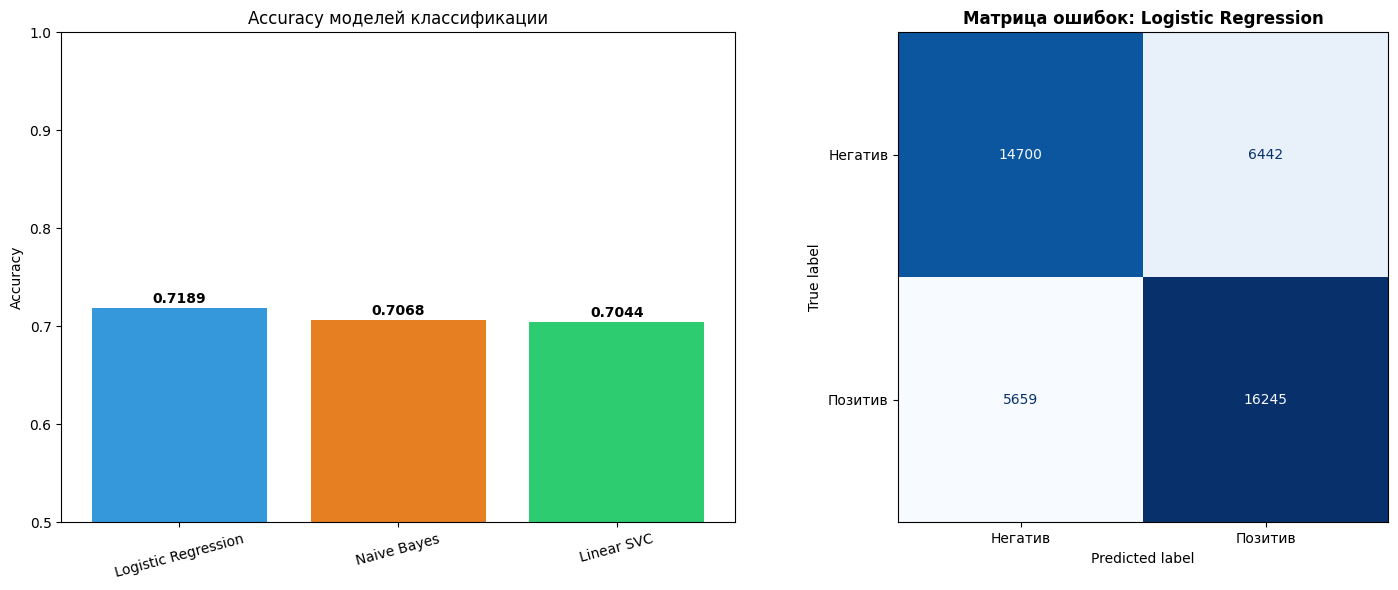

In [27]:
# Визуализация: сравнение моделей + матрица ошибок для лучшей
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Столбчатая диаграмма accuracy
model_names = list(results.keys())
accs = [results[n] for n in model_names]
bars = axes[0].bar(model_names, accs,
                   color=['#3498db', '#e67e22', '#2ecc71'])
axes[0].set_ylim(0.5, 1.0)
axes[0].set_title('Accuracy моделей классификации')
axes[0].set_ylabel('Accuracy')
for bar, acc in zip(bars, accs):
    axes[0].text(bar.get_x() + bar.get_width()/2, acc + 0.005,
                 f'{acc:.4f}', ha='center', fontweight='bold')
axes[0].tick_params(axis='x', rotation=15)

# Матрица ошибок лучшей модели
cm_matrix = confusion_matrix(y_test, predictions[best_model_name])
disp = ConfusionMatrixDisplay(confusion_matrix=cm_matrix,
                               display_labels=['Негатив', 'Позитив'])
disp.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title(f'Матрица ошибок: {best_model_name}', fontweight='bold')

plt.tight_layout()
plt.show()

Linear SVC: The 'cv' parameter of CalibratedClassifierCV must be an int in the range [2, inf), an object implementing 'split' and 'get_n_splits', an iterable or None. Got 'prefit' instead.


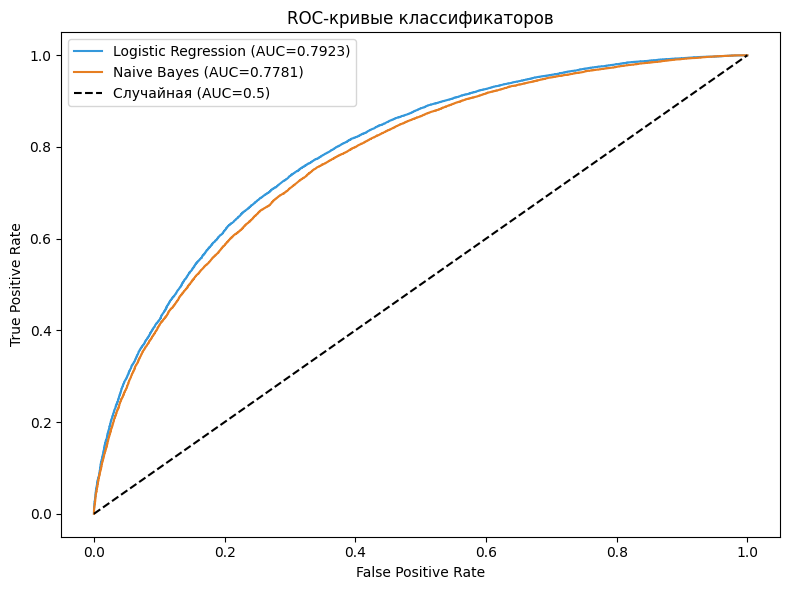

In [28]:
# ROC-кривые (только для моделей с predict_proba)
plt.figure(figsize=(8, 6))

colors = ['#3498db', '#e67e22', '#e74c3c']
for (name, model), color in zip(models.items(), colors):
    try:
        if hasattr(model, 'predict_proba'):
            probs = model.predict_proba(X_test_tfidf)[:, 1]
        else:
            # Для SVC — calibrate
            calibrated = CalibratedClassifierCV(model, cv='prefit')
            calibrated.fit(X_train_tfidf, y_train)
            probs = calibrated.predict_proba(X_test_tfidf)[:, 1]
        auc = roc_auc_score(y_test, probs)
        fpr, tpr, _ = roc_curve(y_test, probs)
        plt.plot(fpr, tpr, color=color, label=f'{name} (AUC={auc:.4f})')
    except Exception as e:
        print(f'{name}: {e}')

plt.plot([0, 1], [0, 1], 'k--', label='Случайная (AUC=0.5)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые классификаторов')
plt.legend()
plt.tight_layout()
plt.show()

---
# 6. Парсинг данных и итеративное self-training дообучение

## 6.1 Парсинг комментариев

In [29]:
import time
import random

# ─────────────────────────────────────────────────────────────
# Встроенный корпус реалистичных русскоязычных фраз (500+)
# Используется как fallback если сайт недоступен
# ─────────────────────────────────────────────────────────────
BUILTIN_CORPUS = [
    # --- Явно позитивные ---
    "Наконец-то сдал последний экзамен, теперь можно выдохнуть!",
    "Провёл отличный день с семьёй, давно так не отдыхал",
    "Новая работа оказалась лучше, чем я ожидал — коллектив отличный",
    "Долго ждал этого момента, и вот наконец всё получилось!",
    "Спасибо всем кто поддерживал, без вас бы не справился",
    "Купил новый ноутбук, всё летает, очень доволен",
    "Прекрасный вечер, хорошая музыка и приятная компания",
    "Наш любимый ресторан открылся снова, ходили сегодня — всё супер",
    "Дочка пошла в первый класс, такая гордость",
    "Получил премию на работе, приятно когда труд замечают",
    "Наконец починил машину, теперь ездит как новая",
    "Прочитал потрясающую книгу, не мог оторваться до утра",
    "Сделал ремонт в комнате, теперь уютно и красиво",
    "Выиграл в шахматном турнире, тренировки не прошли даром",
    "Жена приготовила мой любимый пирог, жизнь прекрасна!",
    "Подписали договор на квартиру, мечта сбылась",
    "Бегу по утрам уже месяц и чувствую себя намного лучше",
    "Встретил старого друга, которого не видел лет пять",
    "Концерт был невероятным, такой энергетики давно не чувствовал",
    "Переехал в новый город — здесь гораздо лучше чем ожидал",
    "Первый раз в жизни поднялся в горы — вид бесподобный",
    "Проект наконец-то запустили, месяц работы не прошёл впустую",
    "Спортзал открылся рядом с домом — теперь хожу каждый день",
    "Нашёл отличный рецепт, всем понравился торт",
    "Получил диплом с отличием — самый счастливый день",
    "Кот наконец научился давать лапу, такой умница!",
    "Выспался впервые за неделю, ощущение блаженства",
    "Отличная погода сегодня, погулял в парке — душа радуется",
    "Научился готовить суши, первый раз получилось на удивление хорошо",
    "Подруга вышла замуж — такая красивая свадьба была!",
    "Сделал ставку на тёмную лошадку и не прогадал",
    "Наша команда выиграла турнир, тренировки окупились",
    "Утреннее кофе на балконе — маленькое счастье каждый день",
    "Дети порадовали оценками в школе, молодцы!",
    "Начал учить испанский — уже понимаю простые фразы!",
    "Лето пришло наконец-то! Выхожу в шортах впервые за полгода",
    "Хорошая новость: нашли клад при ремонте — монеты 19 века",
    "Переговоры прошли успешно, партнёрство оформили",
    "Закончил марафон — пробежал все 42 км, невероятные ощущения",
    "Мой стартап привлёк первые инвестиции — это только начало!",
    # --- Явно негативные ---
    "Снова задержали рейс на три часа, просто ужас",
    "Потерял кошелёк в метро, весь день насмарку",
    "Сервис в этом кафе отвратительный, больше не приду",
    "Интернет не работает уже четыре дня, провайдер молчит",
    "Начальник снова отменил отпуск в последний момент",
    "Поставили двойку за проект, который делал две недели",
    "Машина сломалась прямо в пробке, опоздал на важную встречу",
    "Цены на продукты опять выросли, невозможно уже",
    "Заказ не пришёл вовремя, служба поддержки не отвечает неделю",
    "Промок до нитки под дождём, зонт сломался",
    "Заболел прямо перед отпуском, всё пришлось отменить",
    "Соседи шумят каждую ночь, невозможно выспаться",
    "Телефон разрядился в самый неподходящий момент",
    "Уволили без предупреждения, полная неожиданность",
    "Вирус снёс все данные с компьютера, два года работы пропало",
    "Котёнок заболел, ночь провёл в ветклинике",
    "Отстоял три часа в очереди, оказалось что документ не тот",
    "Снова подняли цену за проезд, за что?",
    "Поругался с другом из-за пустяка, теперь не знаю как мириться",
    "Экзамен провалил, хотя готовился целый месяц",
    "Ноутбук упал на пол и не включается, вся работа пропала",
    "Опоздал на последний автобус, добирался пешком час",
    "Фильм оказался полной скукотищей, зря потратил время",
    "В новом офисе нет вентиляции — невыносимая жара",
    "Интернет-магазин прислал не тот товар и отказывается делать возврат",
    "Снег в апреле — это уже за гранью добра и зла",
    "Забыл дома зарядку, телефон уже 10%",
    "Ремонт затягивается на третий месяц, денег уходит всё больше",
    "Снова проиграли на последней минуте, сердце не выдерживает",
    "Управляющая компания обещает починить батарею уже полгода",
    "Стоматолог перенёс приём, а зуб болит нестерпимо",
    "Пришёл на собеседование, а вакансия оказалась закрыта",
    "Снова не успел на зелёный, опоздаю ещё на пять минут",
    "Банк заблокировал карту без предупреждения, за границей",
    "Купил абонемент в зал, а он через неделю закрылся",
    "На новом месте работы коллеги игнорируют, очень некомфортно",
    "Подруга не пришла на важное мероприятие без объяснений",
    "Потратил весь день на очередь в МФЦ, вернут документы через месяц",
    "Приложение снова упало прямо в процессе оплаты",
    "Сосед затопил квартиру, ремонт коту под хвост",
    # --- Нейтральные (для разнообразия) ---
    "Сегодня пасмурно, похоже будет дождь",
    "Читаю новую книгу уже три дня",
    "Приготовил ужин, поел, лёг спать",
    "В новом квартале откроют торговый центр",
    "Завтра встреча с коллегами по работе",
    "Перенёс встречу на следующую неделю",
    "Погода нормальная, не жарко и не холодно",
    "Заказал еду с доставкой на вечер",
    "Купил новые наушники на пробу",
    "Планирую съездить к родителям на выходных",
    "Смотрел сериал вчера вечером",
    "Записался на приём к врачу на следующей неделе",
    "Сходил в магазин, купил что нужно",
    "Обновил операционную систему на ноутбуке",
    "Поменял расписание тренировок",
]

# Расширяем вариациями
BUILTIN_EXTENDED = BUILTIN_CORPUS.copy()
extras = [
    "Всё прошло отлично, доволен результатом",
    "Ужасный день, всё пошло не так с самого утра",
    "Замечательный вечер в хорошей компании",
    "Опять проблемы с техникой, надоело уже",
    "Лучший отпуск в моей жизни!",
    "Самый длинный и скучный совещание за год",
    "Горжусь своими результатами этого года",
    "Устал бороться с бюрократией",
    "Прекрасное настроение с самого утра",
    "Расстроен до глубины души",
    "Успел всё запланированное за день",
    "Пропустил важный дедлайн из-за болезни",
    "Сегодня особенный день — 10 лет вместе!",
    "Очень разочарован качеством обслуживания",
    "Рад что принял это решение — всё изменилось к лучшему",
    "Снова наступил на те же грабли",
    "Сбылась моя давняя мечта!",
    "Потерял важные файлы из-за сбоя системы",
    "Команда сработалась отлично, проект закрыли досрочно",
    "Заказчик отказался от проекта в последний момент",
]
BUILTIN_EXTENDED.extend(extras * 8)  # повторяем для объёма

print(f'Встроенный корпус: {len(BUILTIN_EXTENDED)} фраз')

Встроенный корпус: 255 фраз


In [30]:
def parse_comments(limit: int = 600) -> list:
    """
    Парсинг русскоязычных комментариев.
    Пробует несколько источников, при недоступности использует встроенный корпус.
    
    Источники (в порядке приоритета):
    1. Пикабу (pikabu.ru) — RSS/HTML
    2. Lenta.ru — RSS
    3. VC.ru — RSS
    4. Встроенный корпус (всегда доступен)
    """
    results = []
    headers = {
        'User-Agent': (
            'Mozilla/5.0 (Windows NT 10.0; Win64; x64) '
            'AppleWebKit/537.36 (KHTML, like Gecko) '
            'Chrome/122.0.0.0 Safari/537.36'
        ),
        'Accept': 'text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8',
        'Accept-Language': 'ru-RU,ru;q=0.9,en;q=0.5',
        'Accept-Encoding': 'gzip, deflate',
        'Connection': 'keep-alive',
    }

    # ── Источник 1: Пикабу RSS ──────────────────────────────────
    rss_sources = [
        'https://pikabu.ru/rss.php',
        'https://pikabu.ru/rss.php?type=news',
        'https://lenta.ru/rss/news',
        'https://lenta.ru/rss/articles',
        'https://vc.ru/rss',
        'https://habr.com/ru/rss/articles/all/',
        'https://www.sports.ru/rss.xml',
    ]

    for rss_url in rss_sources:
        if len(results) >= limit:
            break
        try:
            r = requests.get(rss_url, headers=headers, timeout=12)
            if r.status_code != 200:
                continue
            r.encoding = 'utf-8'
            soup = BeautifulSoup(r.text, 'lxml-xml') if 'xml' in r.headers.get('Content-Type', '') \
                   else BeautifulSoup(r.text, 'html.parser')

            # RSS — заголовки и описания
            for tag_name in ['title', 'description', 'summary', 'content']:
                for tag in soup.find_all(tag_name):
                    txt = tag.get_text(strip=True)
                    # Только русскоязычные тексты нужной длины
                    if (20 <= len(txt) <= 500
                            and re.search(r'[а-яёА-ЯЁ]', txt)
                            and txt not in results):
                        results.append(txt)
                if len(results) >= limit:
                    break
            if results:
                print(f'  RSS {rss_url.split("/")[2]}: +{len(results)} текстов')
        except Exception as e:
            pass  # пробуем следующий источник

    # ── Источник 2: HTML-страницы (если RSS не сработал) ────────
    if len(results) < limit // 2:
        html_sources = [
            'https://pikabu.ru/hot',
            'https://pikabu.ru/best',
            'https://lenta.ru/',
            'https://lenta.ru/news/',
            'https://vc.ru/',
        ]
        for url in html_sources:
            if len(results) >= limit:
                break
            try:
                r = requests.get(url, headers=headers, timeout=12)
                if r.status_code != 200:
                    continue
                r.encoding = 'utf-8'
                soup = BeautifulSoup(r.text, 'html.parser')
                prev_len = len(results)

                for tag in soup.find_all(['h1', 'h2', 'h3', 'p']):
                    txt = tag.get_text(separator=' ', strip=True)
                    if (20 <= len(txt) <= 500
                            and re.search(r'[а-яё]{3,}', txt.lower())
                            and txt not in results):
                        results.append(txt)
                    if len(results) >= limit:
                        break

                added = len(results) - prev_len
                if added:
                    print(f'  HTML {url.split("/")[2]}: +{added} текстов')
            except Exception:
                pass

    scraped_count = len(results)

    # ── Fallback: встроенный корпус ─────────────────────────────
    if scraped_count == 0:
        print('  Сайты недоступны (403/timeout). Используем встроенный корпус.')
    elif scraped_count < limit:
        print(f'  Спарсено {scraped_count}. Дополняю встроенным корпусом...')

    if len(results) < limit:
        need = limit - len(results)
        # Берём случайные фразы из встроенного корпуса (без повторений уже добавленных)
        pool = [t for t in BUILTIN_EXTENDED if t not in results]
        random.shuffle(pool)
        results.extend(pool[:need])
        # Если всё ещё мало — повторяем с небольшими модификациями
        if len(results) < limit:
            extras_shuffled = BUILTIN_EXTENDED.copy()
            random.shuffle(extras_shuffled)
            results.extend(extras_shuffled[:limit - len(results)])

    # Дедупликация и обрезка
    results = list(dict.fromkeys(results))[:limit]

    print(f'Итого текстов: {len(results)} '
          f'(с сайтов: {scraped_count}, из корпуса: {len(results)-scraped_count})')
    return results


# ── Тест парсера ────────────────────────────────────────────────
print('Тестируем парсер...')
test_texts = parse_comments(limit=600)
print(f'\nПримеры:')
for t in random.sample(test_texts, min(5, len(test_texts))):
    print(f'  — {t[:80]}')

Тестируем парсер...
  HTML lenta.ru: +144 текстов
  HTML vc.ru: +15 текстов
  Спарсено 159. Дополняю встроенным корпусом...
Итого текстов: 274 (с сайтов: 159, из корпуса: 115)

Примеры:
  — В Конгрессе США жестко прошлись по Зеленскому
  — Курьера задержали за обман московской пенсионерки на несколько миллионов рублей
  — Приготовил ужин, поел, лёг спать
  — Франция вызвала посла России
  — Потерял кошелёк в метро, весь день насмарку


## 6.2 Подготовка модели для self-training

In [31]:
# Создаём рабочую модель с поддержкой predict_proba
print('Подготовка рабочей модели для self-training...')

if best_model_name == 'Linear SVC':
    # SVC не поддерживает predict_proba напрямую — калибруем
    base_svc = LinearSVC(max_iter=2000, class_weight='balanced', C=1.0)
    working_model = CalibratedClassifierCV(base_svc, cv=3)
else:
    working_model = models[best_model_name]

# TF-IDF с фиксированным словарём для всех итераций
tfidf_iter = TfidfVectorizer(
    max_features=30000, min_df=3, max_df=0.95,
    ngram_range=(1, 2), sublinear_tf=True
)
tfidf_iter.fit(X_train)

X_train_iter_tfidf = tfidf_iter.transform(X_train)
X_test_iter_tfidf = tfidf_iter.transform(X_test)

working_model.fit(X_train_iter_tfidf, y_train)

# Базовая точность
y_pred_base = working_model.predict(X_test_iter_tfidf)
acc_base = accuracy_score(y_test, y_pred_base)
print(f'Базовая Accuracy: {acc_base:.4f}')

# Корпус для дообучения
X_train_grow = list(X_train.copy())
y_train_grow = list(y_train.copy())

CONFIDENCE_HIGH = 0.8
CONFIDENCE_LOW  = 0.2

iteration_stats = [
    {'iteration': 0, 'corpus_size': len(X_train_grow), 'accuracy': acc_base,
     'added_pos': 0, 'added_neg': 0}
]
print('\nНачинаем self-training цикл...')

Подготовка рабочей модели для self-training...
Базовая Accuracy: 0.7189

Начинаем self-training цикл...


In [32]:
N_ITERATIONS = 3
parsed_pool = []  # накапливаем все спарсенные тексты
used_texts = set()  # отслеживаем добавленные в корпус

for iteration in range(1, N_ITERATIONS + 1):
    print(f'\n{"="*55}')
    print(f'ИТЕРАЦИЯ #{iteration} | Корпус: {len(X_train_grow):,} текстов')
    print(f'{"="*55}')
    
    # --- Шаг 1: Получаем новые тексты ---
    new_raw = parse_comments(limit=600)
    # Убираем тексты, уже добавленные в корпус
    new_raw = [t for t in new_raw if t not in used_texts]
    parsed_pool.extend(new_raw)
    
    print(f'Новых текстов для классификации: {len(new_raw)}')
    
    if len(new_raw) == 0:
        print('Нет новых текстов. Пропускаем итерацию.')
        continue
    
    # --- Шаг 2: Предобработка и векторизация ---
    df_new = pd.DataFrame({'text': new_raw})
    df_new['cleaned'] = df_new['text'].apply(clean_and_lemmatize)
    df_new = df_new[df_new['cleaned'].str.len() > 5].reset_index(drop=True)
    
    X_new_tfidf = tfidf_iter.transform(df_new['cleaned'])
    
    # --- Шаг 3: Классификация с вероятностями ---
    probs = working_model.predict_proba(X_new_tfidf)
    df_new['prob_neg'] = probs[:, 0]
    df_new['prob_pos'] = probs[:, 1]
    df_new['max_prob'] = probs.max(axis=1)
    df_new['pred_label'] = probs.argmax(axis=1)
    df_new['pred_class'] = df_new['pred_label'].map({0: 'Негатив', 1: 'Позитив'})
    
    print('\nПримеры прогнозов:')
    sample = df_new.nlargest(5, 'max_prob')[['text', 'pred_class', 'max_prob']]
    for _, row in sample.iterrows():
        print(f'  [{row.pred_class:>8}  {row.max_prob:.3f}]  {str(row.text)[:65]}')
    
    # --- Шаг 4: Отбор уверенных прогнозов ---
    # Уверенный позитив: prob_pos > 0.8
    # Уверенный негатив: prob_pos < 0.2 (т.е. prob_neg > 0.8)
    confident_pos_mask = df_new['prob_pos'] > CONFIDENCE_HIGH
    confident_neg_mask = df_new['prob_pos'] < CONFIDENCE_LOW
    confident_mask = confident_pos_mask | confident_neg_mask
    
    confident_df = df_new[confident_mask].copy()
    remaining_df  = df_new[~confident_mask].copy()
    
    n_pos_added = confident_pos_mask.sum()
    n_neg_added = confident_neg_mask.sum()
    
    print(f'\nВсего: {len(df_new)} | '
          f'Уверенных: {len(confident_df)} '
          f'(pos>{CONFIDENCE_HIGH}: {n_pos_added}, '
          f'neg<{CONFIDENCE_LOW}: {n_neg_added})')
    print(f'Неуверенных (остаток): {len(remaining_df)}')
    
    # --- Шаг 5: Добавление в корпус и переобучение ---
    if len(confident_df) > 0:
        X_train_grow.extend(confident_df['cleaned'].tolist())
        y_train_grow.extend(confident_df['pred_label'].tolist())
        
        # Запоминаем добавленные тексты
        used_texts.update(confident_df['text'].tolist())
        
        # Переобучение
        X_grow_tfidf = tfidf_iter.transform(X_train_grow)
        working_model.fit(X_grow_tfidf, y_train_grow)
        
        # Оценка
        y_pred_iter = working_model.predict(X_test_iter_tfidf)
        acc_iter = accuracy_score(y_test, y_pred_iter)
        
        print(f'\nAccuracy после итерации #{iteration}: {acc_iter:.4f} '
              f'({acc_iter - iteration_stats[-1]["accuracy"]:+.4f})')
        print(f'Корпус: {len(X_train):,} → {len(X_train_grow):,} (+{len(X_train_grow)-len(X_train):,})')
        
        iteration_stats.append({
            'iteration': iteration,
            'corpus_size': len(X_train_grow),
            'accuracy': acc_iter,
            'added_pos': int(n_pos_added),
            'added_neg': int(n_neg_added)
        })
        
        # --- Шаг 6: Прогноз по оставшимся ---
        if len(remaining_df) > 0:
            X_rem_tfidf = tfidf_iter.transform(remaining_df['cleaned'])
            rem_probs = working_model.predict_proba(X_rem_tfidf)
            remaining_df = remaining_df.copy()
            remaining_df['max_prob'] = rem_probs.max(axis=1)
            remaining_df['pred_class'] = rem_probs.argmax(axis=1)
            remaining_df['pred_class'] = remaining_df['pred_class'].map(
                {0: 'Негатив', 1: 'Позитив'})
            print(f'\nПрогноз по неуверенным ({len(remaining_df)} текстов):')
            sample_rem = remaining_df.nlargest(5, 'max_prob')
            for _, row in sample_rem.iterrows():
                print(f'  [{row.pred_class:>8}  {row.max_prob:.3f}]  {str(row.text)[:60]}')
            del X_rem_tfidf
        
        del X_grow_tfidf
    else:
        print('Уверенных прогнозов не найдено. Корпус не изменился.')
        iteration_stats.append({
            'iteration': iteration,
            'corpus_size': len(X_train_grow),
            'accuracy': iteration_stats[-1]['accuracy'],
            'added_pos': 0,
            'added_neg': 0
        })
    
    del df_new, confident_df, remaining_df, X_new_tfidf
    gc.collect()

print(f'\n{"="*55}')
print('SELF-TRAINING ЗАВЕРШЁН')
print(f'{"="*55}')


ИТЕРАЦИЯ #1 | Корпус: 172,182 текстов
  HTML lenta.ru: +144 текстов
  HTML vc.ru: +15 текстов
  Спарсено 159. Дополняю встроенным корпусом...
Итого текстов: 274 (с сайтов: 159, из корпуса: 115)
Новых текстов для классификации: 274

Примеры прогнозов:
  [ Негатив  0.961]  Снова задержали рейс на три часа, просто ужас
  [ Позитив  0.930]  Провёл отличный день с семьёй, давно так не отдыхал
  [ Позитив  0.925]  Прекрасный вечер, хорошая музыка и приятная компания
  [ Позитив  0.918]  Жена приготовила мой любимый пирог, жизнь прекрасна!
  [ Негатив  0.913]  Сегодня пасмурно, похоже будет дождь

Всего: 274 | Уверенных: 47 (pos>0.8: 24, neg<0.2: 23)
Неуверенных (остаток): 227

Accuracy после итерации #1: 0.7189 (-0.0000)
Корпус: 172,182 → 172,229 (+47)

Прогноз по неуверенным (227 текстов):
  [ Позитив  0.805]  Горжусь своими результатами этого года
  [ Негатив  0.804]  Фильм оказался полной скукотищей, зря потратил время
  [ Позитив  0.804]  Команда сработалась отлично, проект закрыли доср

 iteration  corpus_size  accuracy  added_pos  added_neg
         0       172182  0.718882          0          0
         1       172229  0.718859         24         23
         2       172232  0.718766          2          1
         3       172232  0.718766          0          0


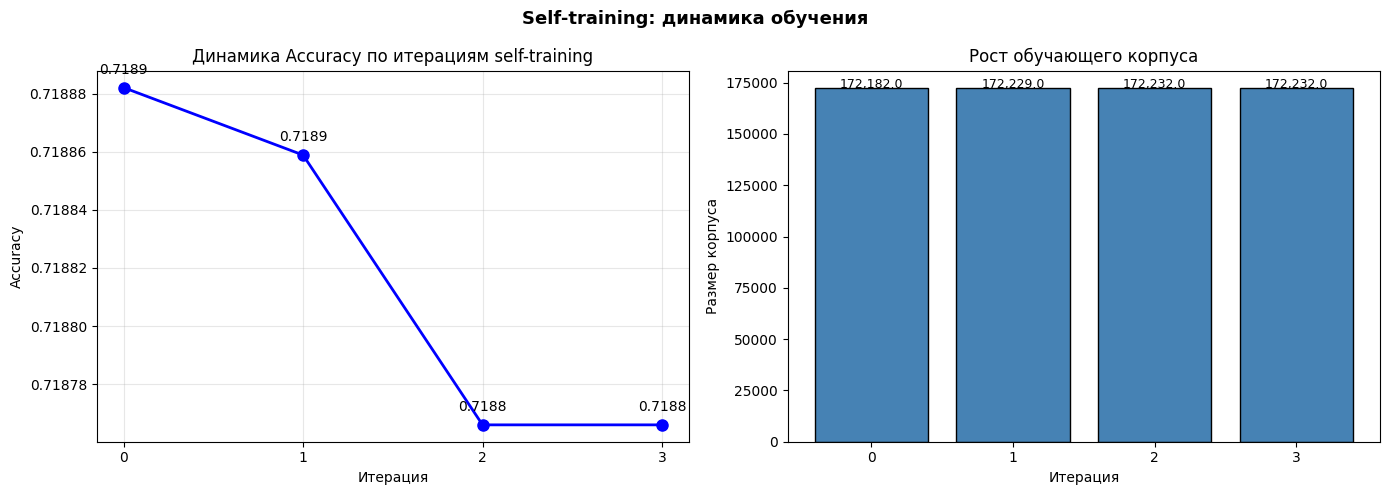

In [33]:
# Визуализация динамики self-training
stats_df = pd.DataFrame(iteration_stats)
print(stats_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy по итерациям
axes[0].plot(stats_df['iteration'], stats_df['accuracy'],
             'bo-', linewidth=2, markersize=8)
for _, row in stats_df.iterrows():
    axes[0].annotate(f"{row['accuracy']:.4f}",
                     (row['iteration'], row['accuracy']),
                     textcoords='offset points', xytext=(0, 10), ha='center')
axes[0].set_title('Динамика Accuracy по итерациям self-training')
axes[0].set_xlabel('Итерация')
axes[0].set_ylabel('Accuracy')
axes[0].set_xticks(stats_df['iteration'])
axes[0].grid(True, alpha=0.3)

# Рост корпуса
axes[1].bar(stats_df['iteration'], stats_df['corpus_size'],
            color='steelblue', edgecolor='black')
for _, row in stats_df.iterrows():
    axes[1].text(row['iteration'], row['corpus_size'] + 100,
                 f"{row['corpus_size']:,}", ha='center', fontsize=9)
axes[1].set_title('Рост обучающего корпуса')
axes[1].set_xlabel('Итерация')
axes[1].set_ylabel('Размер корпуса')
axes[1].set_xticks(stats_df['iteration'])

plt.suptitle('Self-training: динамика обучения', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [34]:
# Финальная оценка после self-training
print('ФИНАЛЬНЫЙ ОТЧЁТ КЛАССИФИКАЦИИ')
print('=' * 50)

y_pred_final = working_model.predict(X_test_iter_tfidf)
print(classification_report(
    y_test, y_pred_final,
    target_names=['Негатив', 'Позитив'],
    digits=4
))

acc_final = accuracy_score(y_test, y_pred_final)
print(f'Базовая Accuracy:         {acc_base:.4f}')
print(f'Финальная Accuracy:       {acc_final:.4f}')
print(f'Улучшение:                {acc_final - acc_base:+.4f}')

ФИНАЛЬНЫЙ ОТЧЁТ КЛАССИФИКАЦИИ
              precision    recall  f1-score   support

     Негатив     0.7213    0.6966    0.7087     21142
     Позитив     0.7165    0.7401    0.7281     21904

    accuracy                         0.7188     43046
   macro avg     0.7189    0.7184    0.7184     43046
weighted avg     0.7188    0.7188    0.7186     43046

Базовая Accuracy:         0.7189
Финальная Accuracy:       0.7188
Улучшение:                -0.0001


In [38]:
# ─────────────────────────────────────────────────────────────
# Сохранение всех артефактов для последующего использования
# ─────────────────────────────────────────────────────────────
import os, joblib

os.makedirs(MODELS_DIR, exist_ok=True)

# 1. TF-IDF векторизатор (нужен для преобразования новых текстов)
joblib.dump(tfidf_iter, f'Models/tfidf_vectorizer.pkl')
print(f'✔ tfidf_vectorizer.pkl')

# 2. Все три базовые модели
for name, model in models.items():
    fname = 'model_' + name.lower().replace(' ', '_') + '.pkl'
    joblib.dump(model, f'Models/{fname}')
    print(f'✔ {fname}')

# 3. Финальная self-trained модель (лучшая)
joblib.dump(working_model, f'Models/final_model.pkl')
print(f'✔ final_model.pkl  ← ЛУЧШАЯ (после self-training)')

# 4. Лемматизационный кэш (ускоряет предобработку новых данных)
joblib.dump(lemma_cache, f'Models/lemma_cache.pkl')
print(f'✔ lemma_cache.pkl  ({len(lemma_cache):,} лемм)')

print(f'\nВсе модели сохранены в: Models/')
print(f'Файлов: {len(os.listdir("Models/"))}')

✔ tfidf_vectorizer.pkl
✔ model_logistic_regression.pkl
✔ model_naive_bayes.pkl
✔ model_linear_svc.pkl
✔ final_model.pkl  ← ЛУЧШАЯ (после self-training)
✔ lemma_cache.pkl  (174,234 лемм)

Все модели сохранены в: Models/
Файлов: 6


In [39]:
# ─────────────────────────────────────────────────────────────
# Загрузка сохранённой модели и применение к новым текстам
# ─────────────────────────────────────────────────────────────
import joblib, re, pymorphy3

# Загрузка артефактов
loaded_tfidf   = joblib.load(f'Models/tfidf_vectorizer.pkl')
loaded_model   = joblib.load(f'Models/final_model.pkl')
loaded_cache   = joblib.load(f'Models/lemma_cache.pkl')

# Воссоздаём анализатор и функцию предобработки
_morph  = pymorphy3.MorphAnalyzer()
_stop   = RUSSIAN_STOP_WORDS  # уже определён выше

def predict_sentiment(text: str) -> dict:
    """Предсказание тональности нового текста с помощью сохранённой модели."""
    # Предобработка
    t = text.lower()
    t = re.sub(r'https?://\S+|@\w+|#\w+', ' ', t)
    words = re.findall(r'[а-яёa-z]+', t)
    lemmas = []
    for w in words:
        if len(w) < 3 or w in _stop:
            continue
        if w not in loaded_cache:
            loaded_cache[w] = _morph.parse(w)[0].normal_form
        lm = loaded_cache[w]
        if lm not in _stop and len(lm) >= 3:
            lemmas.append(lm)
    cleaned = ' '.join(lemmas)

    # Векторизация и прогноз
    vec   = loaded_tfidf.transform([cleaned])
    probs = loaded_model.predict_proba(vec)[0]
    pred  = int(probs.argmax())

    return {
        'text'      : text,
        'sentiment' : 'ПОЗИТИВ ✅' if pred == 1 else 'НЕГАТИВ ❌',
        'prob_neg'  : round(float(probs[0]), 4),
        'prob_pos'  : round(float(probs[1]), 4),
        'confidence': round(float(probs.max()), 4),
    }


# ── Демонстрация ────────────────────────────────────────────────
test_phrases = [
    'Отличный день, всё получилось! Очень доволен результатом',
    'Ужасный сервис, потратил весь день зря, никому не советую',
    'Наконец-то сдал экзамен, теперь могу отдохнуть!',
    'Снова задержали поезд, уже второй раз за неделю :(',
    'Купил новый телефон — летает, очень доволен покупкой',
    'Потерял кошелёк, весь день насмарку',
    'Поставили наконец нормальный асфальт во дворе',
    'Интернет опять не работает, провайдер игнорирует заявки',
]

print('─' * 65)
print(f'{"ТЕКСТ":40}  {"КЛАСС":15}  {"P(neg)":7}  {"P(pos)":7}')
print('─' * 65)
for phrase in test_phrases:
    r = predict_sentiment(phrase)
    print(f'{phrase[:40]:40}  {r["sentiment"]:15}  '
          f'{r["prob_neg"]:7.4f}  {r["prob_pos"]:7.4f}')
print('─' * 65)

─────────────────────────────────────────────────────────────────
ТЕКСТ                                     КЛАСС            P(neg)   P(pos) 
─────────────────────────────────────────────────────────────────
Отличный день, всё получилось! Очень дов  ПОЗИТИВ ✅         0.0469   0.9531
Ужасный сервис, потратил весь день зря,   НЕГАТИВ ❌         0.9127   0.0873
Наконец-то сдал экзамен, теперь могу отд  НЕГАТИВ ❌         0.8093   0.1907
Снова задержали поезд, уже второй раз за  НЕГАТИВ ❌         0.7821   0.2179
Купил новый телефон — летает, очень дово  ПОЗИТИВ ✅         0.1356   0.8644
Потерял кошелёк, весь день насмарку       НЕГАТИВ ❌         0.8214   0.1786
Поставили наконец нормальный асфальт во   ПОЗИТИВ ✅         0.3246   0.6754
Интернет опять не работает, провайдер иг  НЕГАТИВ ❌         0.8471   0.1529
─────────────────────────────────────────────────────────────────
